In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
from sympy import *

In [2]:
eps = 0.4; beta = 0.1; d = 2
i = Symbol('i',integer=True); k = Symbol('k',integer=True); n = Symbol('n',integer=True)
g1 = summation(((exp(beta*(k+1)*(d-i)))/(eps**(d-i)))*(((exp(beta)/(exp(beta)-1))*(exp(beta*k)-1))**i)/factorial(i),(i,0,d-1))
g2 = summation(((exp(beta*(k+1)*(d-i)))/(eps**(d-i)))*(((exp(beta)/(exp(beta)-1))*(exp(beta*(k+1))-1))**i)/factorial(i),(i,0,d-1))
f = summation((1/exp(eps*k))*(g1-(1/exp(eps))*g2),(k,0,n))
l = limit(f,n,oo)
a = 1/(l*(2**d))
print(a.evalf())

0.0135386189518576


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


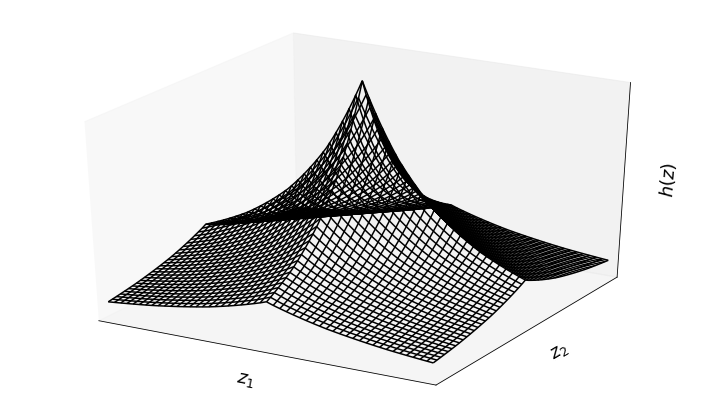

In [3]:
def b(k):
    beta = 0.1
    return (math.exp(beta)/(math.exp(beta)-1))*(math.exp(beta*k)-1)

def h(z1,z2):
    if math.fabs(z1)+math.fabs(z2) < math.exp(beta):
        k = 0
    elif math.fabs(z1)+math.fabs(z2) < math.exp(beta)+math.exp(2*beta):
        k = 1
    elif math.fabs(z1)+math.fabs(z2) < math.exp(beta)+math.exp(2*beta)+math.exp(3*beta):
        k = 2
    elif math.fabs(z1)+math.fabs(z2) < math.exp(beta)+math.exp(2*beta)+math.exp(3*beta)+math.exp(4*beta):
        k = 3
    elif math.fabs(z1)+math.fabs(z2) < math.exp(beta)+math.exp(2*beta)+math.exp(3*beta)+math.exp(4*beta)+math.exp(5*beta):
        k = 4
    elif math.fabs(z1)+math.fabs(z2) < math.exp(beta)+math.exp(2*beta)+math.exp(3*beta)+math.exp(4*beta)+math.exp(5*beta)+math.exp(6*beta):
        k = 5
    else:
        k = 6
    return a*(1/math.exp(eps*k))*math.exp(-(eps/math.exp(beta*(k+1)))*(math.fabs(z1)+math.fabs(z2)-b(k)))

n = 1000
z1 = np.linspace(-5,5,n); z2 = np.linspace(-5,5,n)
Z1, Z2 = np.meshgrid(z1, z2)
X = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        X[i][j] = h(Z1[i][j], Z2[i][j])
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot_wireframe(Z1,Z2,X,color='k')
ax.set_xlim(-5,5); ax.set_ylim(-5,5); ax.set_zlim(0,0.012)
ax.set_xticks([100]); ax.set_yticks([100]); ax.set_zticks([100])
ax.set_xlabel("$z_1$", fontsize = 18)
ax.set_ylabel("$z_2$", fontsize = 18)
ax.set_zlabel("$h(z)$", fontsize = 18)
plt.subplots_adjust(left=0.15, right=1.75, top=1.55, bottom=0.15)
fig.savefig("SID_example_d=2.png")
fig.savefig("figs/SID_example_d=2.eps", bbox_inches="tight", pad_inches=0.05)